In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load dog image and plot it

Pixel max and min:
255 0
Number of unique pixel intensities in image:  256


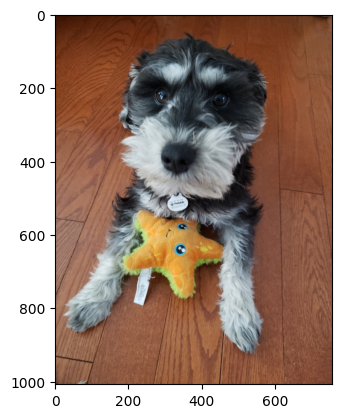

In [ ]:
# load dog image
from matplotlib import image
import numpy as np

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = image.imread(work_path + 'Data/Dog.jpg')
img = np.transpose(img, (0,1,2))

# plot image
import matplotlib.pyplot as plt
plt.imshow(img)

print('Pixel max and min:')
print(img.max(), img.min())

uni = np.unique(img)
print('Number of unique pixel intensities in image: ',len(uni))

# Average Sampleing and zero-hold-order upsampling

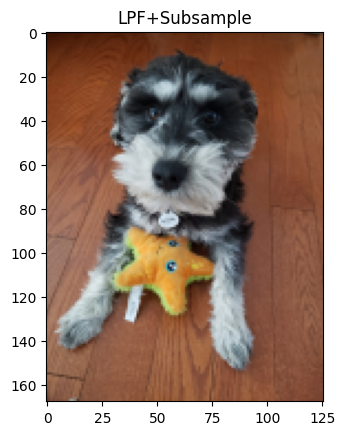

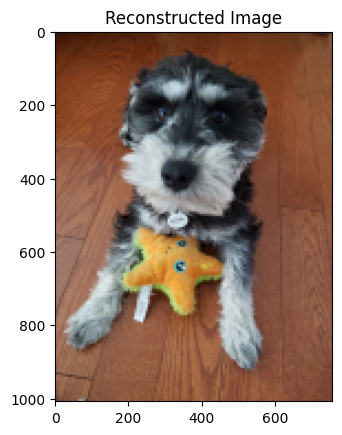

In [ ]:

def avg_sampling(C, size):
    dim = int(C.shape[2])
    wid = int(C.shape[0] / size)
    hei = int(C.shape[1] / size)
    S = np.zeros((wid, hei,dim))
    for i0_mean in range(dim):
        for i1_mean in range(wid):
            for i2_mean in range(hei):
                S[i1_mean, i2_mean,i0_mean] = np.mean(
                    C[i1_mean * size:i1_mean * size + size,
                    i2_mean * size:i2_mean * size + size, i0_mean])
    return S


def zho_upsampling(S, size):
    dim = int(S.shape[2])
    wid = int(S.shape[0] * size)
    hei = int(S.shape[1] * size)
    C = np.zeros((wid, hei,dim))
    for i0 in range(dim):
        for i1_inv in range(S.shape[0]):
            for i2_inv in range(S.shape[1]):
                C[i1_inv * size:i1_inv * size + size, i2_inv * size:i2_inv * size + size, i0] = S[i1_inv, i2_inv, i0]
    return C


size = 6
img_s = avg_sampling(img,size)
img_c = zho_upsampling(img_s,size)
plt.figure()
plt.title('LPF+Subsample')
plt.imshow(img_s.astype(int))

plt.figure()
plt.title('Reconstructed Image')
plt.imshow(img_c.astype(int))

# Subsampling **WITHOUT** averaging and ZHO Reconstruction

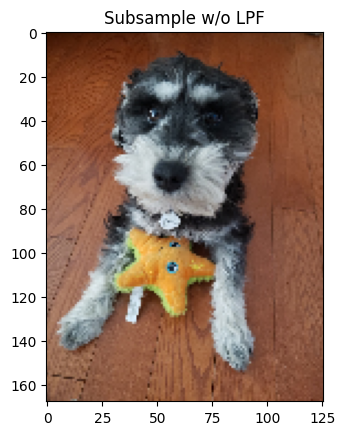

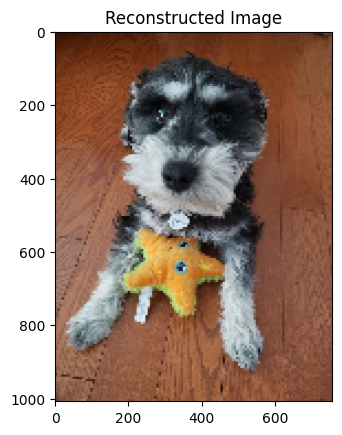

In [ ]:
sample_interval = size
index0 = np.arange(0, img.shape[0], sample_interval, dtype=int)
index1 = np.arange(0, img.shape[1], sample_interval, dtype=int)

new_img = img[index0]
new_img = new_img[:,index1,:]
plt.figure()
plt.title('Subsample w/o LPF')
plt.imshow(new_img)

plt.figure()
plt.title('Reconstructed Image')
subsampling_c = zho_upsampling(new_img,size)
plt.imshow(subsampling_c.astype(int))

# Zoomed-in sampled details near Star

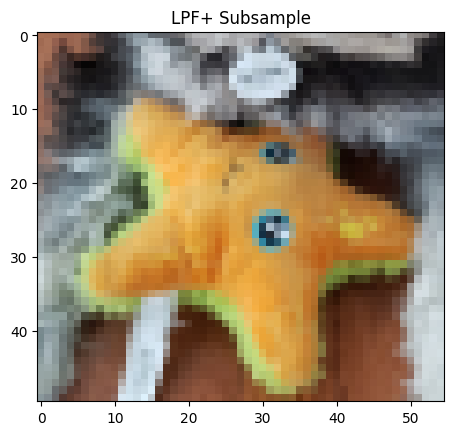

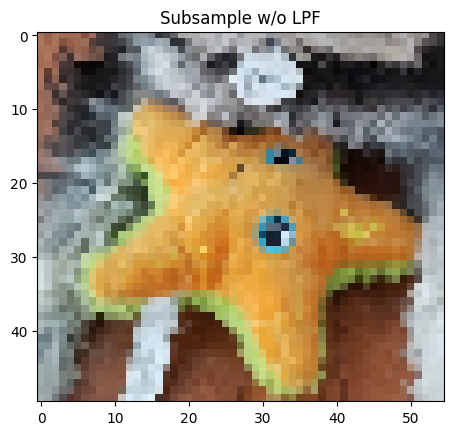

In [ ]:
star_top = 80
star_bottom = 130
star_left = 25
star_right = 80

plt.figure()
plt.title('LPF+ Subsample')
plt.imshow(img_s[star_top:star_bottom, star_left:star_right, :].astype(int))

plt.figure()
plt.title('Subsample w/o LPF')
plt.imshow(new_img[star_top:star_bottom, star_left:star_right, :].astype(int))

# Zoomed-in reconstructed details near Star

---



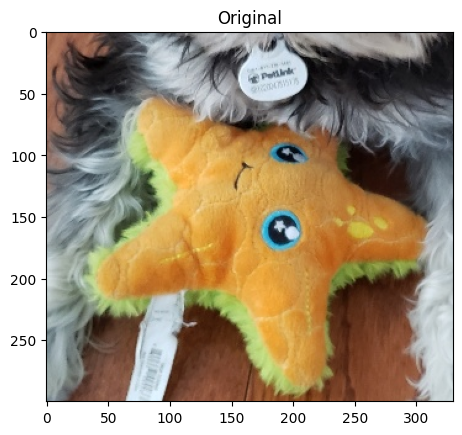

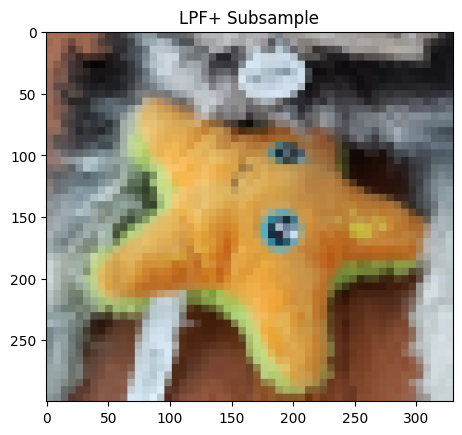

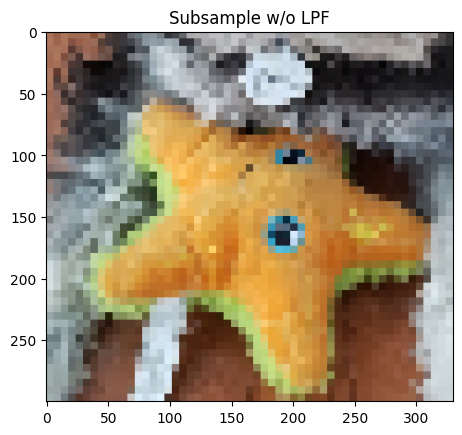

In [ ]:
star_top = 480
star_bottom = 780
star_left = 150
star_right = 480

plt.figure()
plt.title('Original')
plt.imshow(img[star_top:star_bottom, star_left:star_right, :])

plt.figure()
plt.title('LPF+ Subsample')
plt.imshow(img_c[star_top:star_bottom, star_left:star_right, :].astype(int))

plt.figure()
plt.title('Subsample w/o LPF')
plt.imshow(subsampling_c[star_top:star_bottom, star_left:star_right, :].astype(int))